In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [2]:
print("numpy version : ",np.__version__)
print("pandas version :",pd.__version__)

numpy version :  2.3.3
pandas version : 2.3.3


In [3]:
np.random.seed(42)

In [35]:
#Normal data
n= 1000
time = np.arange(n)
normal_data = np.sin(time * 0.02) + np.random.normal(0,0.1,n)

In [36]:
anomaly_indices = [200, 400, 600, 800]
for idx in anomaly_indices:
    normal_data[idx] += 2

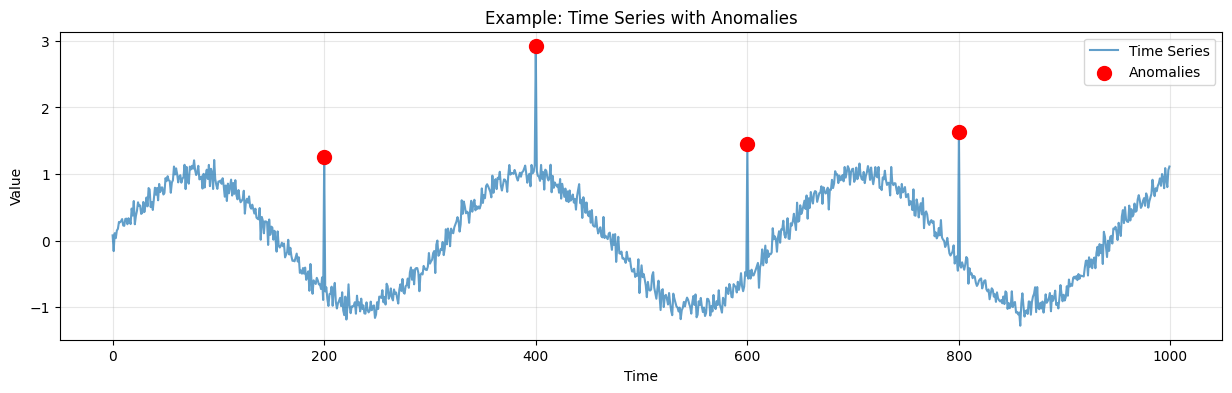

In [37]:
plt.figure(figsize=(15, 4))
plt.plot(time, normal_data, label='Time Series', alpha=0.7)
plt.scatter(anomaly_indices, normal_data[anomaly_indices], 
           color='red', s=100, label='Anomalies', zorder=5)
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Example: Time Series with Anomalies')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [3]:
import os
import numpy as np
import pandas as pd
from TSB_UAD.models.iforest import IForest
from TSB_UAD.models.feature import Window
from TSB_UAD.utils.slidingWindows import find_length
from TSB_UAD.vus.metrics import get_metrics
from sklearn
df = pd.read_csv('TSB-UAD/data/benchmark/ECG/MBA_ECG805_data.out', header=None).to_numpy()
data = df[:, 0].astype(float)
label = df[:, 1]

slidingWindow = find_length(data)
X_data = Window(window = slidingWindow).convert(data).to_numpy()

clf = IForest(n_jobs=1)
clf.fit(X_data)
score = clf.decision_scores_

score = MinMaxScaler(feature_range=(0,1)).fit_transform(score.reshape(-1,1)).ravel()
score = np.array([score[0]]*math.ceil((slidingWindow-1)/2) + list(score) + [score[-1]]*((slidingWindow-1)//2))


results = get_metrics(score, label, metric="all", slidingWindow=slidingWindow)
for metric in results.keys():
    print(metric, ':', results[metric])

NameError: name 'MinMaxScaler' is not defined